# RS-CLIP, but tiny, on real WorldCover ROIs

This notebook is the contrastive-learning counterpart to the BharatEO-v0 MAE post. The data and chips are the same — three real ESA WorldCover 2021 v200 ROIs from the N27E075 tile (Delhi NCR, Shekhawati, the Mathura cropland belt) — but the objective is different.

Instead of masked reconstruction, we train two small encoders side by side:

- an **image encoder** that turns a `128 x 128` RGB chip into a fixed-length embedding,
- a **text encoder** that turns a short land-cover caption into the same kind of embedding,

and we pull matching image / text pairs together while pushing non-matches apart, exactly like CLIP. This is the essence of RS-CLIP-style remote-sensing vision-language models, scaled down to something that runs in a couple of minutes on CPU.

The win: once trained, you can do **zero-shot land cover classification** by comparing each image embedding to a small set of class-template text embeddings (`"an aerial view of cropland"`, `"an aerial view of built-up urban area"`, ...) and picking the most similar one.

Caveats up front:

- The chip is still a colorized rendering of WorldCover classes, not Sentinel-2 reflectance. So the alignment task is easier than the real RS-CLIP problem, and the headline numbers are inflated. Treat them as a sanity check, not a benchmark.
- The captions are templated from the dominant collapsed class plus an optional secondary class. They are not human-written.
- The encoders are deliberately tiny (~1-2 M params each).

## Setup, seeds, and shared constants

Most of this is identical to the MAE post so the two notebooks can be read independently.

In [1]:
from pathlib import Path
import os
import random
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

%matplotlib inline
%config InlineBackend.figure_format = "retina"

import numpy as np
import matplotlib.pyplot as plt

import rasterio
from rasterio.windows import Window

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 240,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings("ignore", message="enable_nested_tensor.*")

device = torch.device("cpu")
print("device:", device)

device: cpu


## Geometry, training budget, and label space

The image side uses the same chip / patch sizes as the MAE post. The text side has a tiny vocabulary because all captions are built from a fixed set of land-cover phrases.

In [2]:
IMG_SIZE = 128
PATCH_SIZE = 16
GRID_SIZE = IMG_SIZE // PATCH_SIZE
NUM_PATCHES = GRID_SIZE * GRID_SIZE
NUM_INPUT_CHANNELS = 3
DATASET_SIZE = 384
BATCH_SIZE = 32
EPOCHS = 25
EMBED_DIM = 128            # joint image-text embedding dim
IMG_HIDDEN = 128           # image encoder width
TEXT_HIDDEN = 128          # text encoder width
MAX_TEXT_LEN = 16
TEMP_INIT = 0.07           # CLIP-style temperature

CLASS_NAMES = [
    "tree",
    "cropland",
    "grass_shrub",
    "built_up",
    "bare_sparse",
    "water",
    "wetland_mangrove",
    "rare_other",
]
NUM_CLASSES = len(CLASS_NAMES)

CLASS_PHRASES = {
    "tree": "trees",
    "cropland": "cropland",
    "grass_shrub": "grassland and shrubs",
    "built_up": "built-up urban area",
    "bare_sparse": "bare or sparsely vegetated land",
    "water": "open water",
    "wetland_mangrove": "wetland",
    "rare_other": "miscellaneous land cover",
}

print(f"chip:   {NUM_INPUT_CHANNELS} x {IMG_SIZE} x {IMG_SIZE}")
print(f"tokens: {NUM_PATCHES} ({GRID_SIZE} x {GRID_SIZE})")
print(f"chips:  {DATASET_SIZE}, epochs: {EPOCHS}, batch: {BATCH_SIZE}")
print(f"joint embedding dim: {EMBED_DIM}, max text length: {MAX_TEXT_LEN}")

chip:   3 x 128 x 128
tokens: 64 (8 x 8)
chips:  384, epochs: 25, batch: 32
joint embedding dim: 128, max text length: 16


## ESA WorldCover collapsed labels

WorldCover v200 has 11 native codes. We collapse them into 8 classes, identical to the MAE post.

In [3]:
NATIVE_TO_COLLAPSED_NAME = {
    10: "tree",
    20: "grass_shrub",
    30: "grass_shrub",
    40: "cropland",
    50: "built_up",
    60: "bare_sparse",
    70: "rare_other",
    80: "water",
    90: "wetland_mangrove",
    95: "wetland_mangrove",
    100: "rare_other",
}
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
NATIVE_TO_COLLAPSED_ID = np.full(256, CLASS_TO_ID["rare_other"], dtype=np.int64)
for code, name in NATIVE_TO_COLLAPSED_NAME.items():
    NATIVE_TO_COLLAPSED_ID[code] = CLASS_TO_ID[name]

CLASS_COLORS = np.array([
    [35, 132, 67],
    [188, 189, 34],
    [127, 191, 123],
    [215, 48, 39],
    [217, 164, 65],
    [49, 130, 189],
    [44, 162, 95],
    [189, 189, 189],
], dtype=np.float32) / 255.0


def collapse_worldcover(native_map):
    return NATIVE_TO_COLLAPSED_ID[native_map]


def labels_to_rgb(labels):
    arr = labels.detach().cpu().numpy() if torch.is_tensor(labels) else labels
    return CLASS_COLORS[arr]


def labels_to_rgb_input(labels):
    return CLASS_COLORS[labels].transpose(2, 0, 1).astype(np.float32)


def patch_mode_labels(label_map):
    blocks = label_map.reshape(GRID_SIZE, PATCH_SIZE, GRID_SIZE, PATCH_SIZE)
    blocks = blocks.transpose(0, 2, 1, 3).reshape(GRID_SIZE, GRID_SIZE, -1)
    out = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.int64)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            out[r, c] = np.bincount(blocks[r, c], minlength=NUM_CLASSES).argmax()
    return out

## Three real WorldCover ROIs from the N27E075 tile

Same three ROIs as the MAE post: Delhi NCR (built-up dominant), Shekhawati (semi-arid Rajasthan), Mathura belt (UP cropland). Each is a `2048 x 2048` 10 m crop, cached locally after the first download.

In [4]:
WORLDCOVER_TILE_URL = "https://esa-worldcover.s3.eu-central-1.amazonaws.com/v200/2021/map/ESA_WorldCover_10m_2021_v200_N27E075_Map.tif"
ROI_SIZE = 2048
ROI_CENTERS = [
    ("delhi_ncr", (77.23, 28.61)),
    ("shekhawati", (75.80, 28.50)),
    ("mathura_belt", (77.50, 27.30)),
]
CACHE_DIR = Path("data")


def load_one_roi(name, lon_lat, cache_dir=CACHE_DIR, roi_size=ROI_SIZE):
    cache_path = cache_dir / f"worldcover_2021_v200_N27E075_{name}_roi_{roi_size}.npz"
    if cache_path.exists():
        cached = np.load(cache_path, allow_pickle=True)
        return cached["roi"], {
            "name": name,
            "bounds": tuple(cached["bounds"].tolist()),
            "center_lon_lat": tuple(cached["center_lon_lat"].tolist()),
        }
    cache_dir.mkdir(parents=True, exist_ok=True)
    with rasterio.open(WORLDCOVER_TILE_URL) as src:
        center_row, center_col = src.index(*lon_lat)
        window = Window(center_col - roi_size // 2, center_row - roi_size // 2, roi_size, roi_size)
        roi = src.read(1, window=window)
        bounds = src.window_bounds(window)
    np.savez_compressed(
        cache_path,
        roi=roi,
        url=np.array(WORLDCOVER_TILE_URL),
        crs=np.array("EPSG:4326"),
        bounds=np.array(bounds, dtype=np.float64),
        center_lon_lat=np.array(lon_lat, dtype=np.float64),
    )
    return roi, {"name": name, "bounds": tuple(bounds), "center_lon_lat": lon_lat}


roi_arrays = []
roi_metas = []
for name, lon_lat in ROI_CENTERS:
    roi, meta = load_one_roi(name, lon_lat)
    roi_arrays.append(roi)
    roi_metas.append(meta)

for meta, roi in zip(roi_metas, roi_arrays):
    print(f"[{meta['name']}] center {meta['center_lon_lat']} shape {roi.shape}")

[delhi_ncr] center (77.23, 28.61) shape (2048, 2048)
[shekhawati] center (75.8, 28.5) shape (2048, 2048)
[mathura_belt] center (77.5, 27.3) shape (2048, 2048)


## Captions

Each chip gets a templated caption derived from its dominant collapsed class, with an optional secondary class if a second class covers more than ~15% of the chip. Concretely:

- pure: `"an aerial view of {dom}"`,
- mixed: `"an aerial view of {dom} with some {second}"`.

This is the kind of weak supervision RS-CLIP papers generate from segmentation masks or external caption banks, just shrunk to a tiny vocabulary so the text encoder can be trained from scratch in this notebook.

In [5]:
SECOND_CLASS_FRACTION = 0.15


def chip_caption(collapsed_chip):
    counts = np.bincount(collapsed_chip.ravel(), minlength=NUM_CLASSES)
    order = np.argsort(-counts)
    dom = CLASS_NAMES[order[0]]
    dom_phrase = CLASS_PHRASES[dom]
    second_id = order[1]
    if counts[second_id] / counts.sum() >= SECOND_CLASS_FRACTION:
        second_phrase = CLASS_PHRASES[CLASS_NAMES[second_id]]
        return f"an aerial view of {dom_phrase} with some {second_phrase}", dom
    return f"an aerial view of {dom_phrase}", dom


for cls in CLASS_NAMES:
    print(f"  {cls:18s} -> 'an aerial view of {CLASS_PHRASES[cls]}'")

  tree               -> 'an aerial view of trees'
  cropland           -> 'an aerial view of cropland'
  grass_shrub        -> 'an aerial view of grassland and shrubs'
  built_up           -> 'an aerial view of built-up urban area'
  bare_sparse        -> 'an aerial view of bare or sparsely vegetated land'
  water              -> 'an aerial view of open water'
  wetland_mangrove   -> 'an aerial view of wetland'
  rare_other         -> 'an aerial view of miscellaneous land cover'


## A tiny word-level tokenizer

The vocabulary covers exactly the words that can appear in our templated captions. We add `[PAD]`, `[SOS]`, `[EOS]` so the text encoder has clear sequence boundaries.

In [6]:
SPECIAL_TOKENS = ["[PAD]", "[SOS]", "[EOS]"]
PAD_ID, SOS_ID, EOS_ID = 0, 1, 2


def caption_corpus():
    corpus = []
    for cls in CLASS_NAMES:
        corpus.append(f"an aerial view of {CLASS_PHRASES[cls]}")
    for a in CLASS_NAMES:
        for b in CLASS_NAMES:
            if a != b:
                corpus.append(f"an aerial view of {CLASS_PHRASES[a]} with some {CLASS_PHRASES[b]}")
    return corpus


vocab_words = []
seen = set(SPECIAL_TOKENS)
for sentence in caption_corpus():
    for word in sentence.split():
        if word not in seen:
            seen.add(word)
            vocab_words.append(word)

VOCAB = SPECIAL_TOKENS + vocab_words
WORD_TO_ID = {w: i for i, w in enumerate(VOCAB)}
VOCAB_SIZE = len(VOCAB)


def tokenize(sentence, max_len=MAX_TEXT_LEN):
    ids = [SOS_ID] + [WORD_TO_ID[w] for w in sentence.split()] + [EOS_ID]
    ids = ids[:max_len]
    pad = max_len - len(ids)
    return ids + [PAD_ID] * pad


def detokenize(ids):
    words = []
    for i in ids:
        if i == EOS_ID:
            break
        if i in (PAD_ID, SOS_ID):
            continue
        words.append(VOCAB[i])
    return " ".join(words)


example = tokenize("an aerial view of cropland")
print("vocab size:", VOCAB_SIZE)
print("max_len:", MAX_TEXT_LEN)
print("example tokens:", example)
print("decoded:       ", detokenize(example))

vocab size: 27
max_len: 16
example tokens: [1, 3, 4, 5, 6, 8, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]
decoded:        an aerial view of cropland


## Dataset

Each item is `(rgb_chip, token_ids, dominant_class_id)`. The dominant class id is only used for evaluation — the encoders never see it during training. Chips are drawn balanced across the three ROIs.

In [7]:
class WorldCoverCLIPDataset(Dataset):
    def __init__(self, roi_natives, n=DATASET_SIZE, chip_size=IMG_SIZE, seed=SEED, min_classes=2):
        self.samples = []
        rng = np.random.default_rng(seed)
        target_per_roi = [n // len(roi_natives)] * len(roi_natives)
        for i in range(n - sum(target_per_roi)):
            target_per_roi[i] += 1

        attempts = 0
        for roi_native, want in zip(roi_natives, target_per_roi):
            collected = 0
            h, w = roi_native.shape
            while collected < want and attempts < n * 400:
                attempts += 1
                row = int(rng.integers(0, h - chip_size))
                col = int(rng.integers(0, w - chip_size))
                collapsed = collapse_worldcover(roi_native[row:row + chip_size, col:col + chip_size])
                if np.unique(collapsed).size < min_classes:
                    continue
                caption, dom = chip_caption(collapsed)
                self.samples.append((
                    labels_to_rgb_input(collapsed),
                    np.array(tokenize(caption), dtype=np.int64),
                    CLASS_TO_ID[dom],
                    caption,
                ))
                collected += 1

        if len(self.samples) != n:
            raise RuntimeError(f"Built {len(self.samples)} chips, expected {n}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rgb, ids, dom_id, _caption = self.samples[idx]
        return torch.from_numpy(rgb), torch.from_numpy(ids), torch.tensor(dom_id, dtype=torch.long)


dataset = WorldCoverCLIPDataset(roi_arrays)
class_balance = np.bincount([s[2] for s in dataset.samples], minlength=NUM_CLASSES)
print("dataset chips:", len(dataset))
print("dominant class distribution:")
for name, count in zip(CLASS_NAMES, class_balance):
    print(f"  {name:18s} {count}")

dataset chips: 384
dominant class distribution:
  tree               44
  cropland           254
  grass_shrub        0
  built_up           86
  bare_sparse        0
  water              0
  wetland_mangrove   0
  rare_other         0


## A few image-caption pairs

These are the kinds of pairs the contrastive loss will pull together.

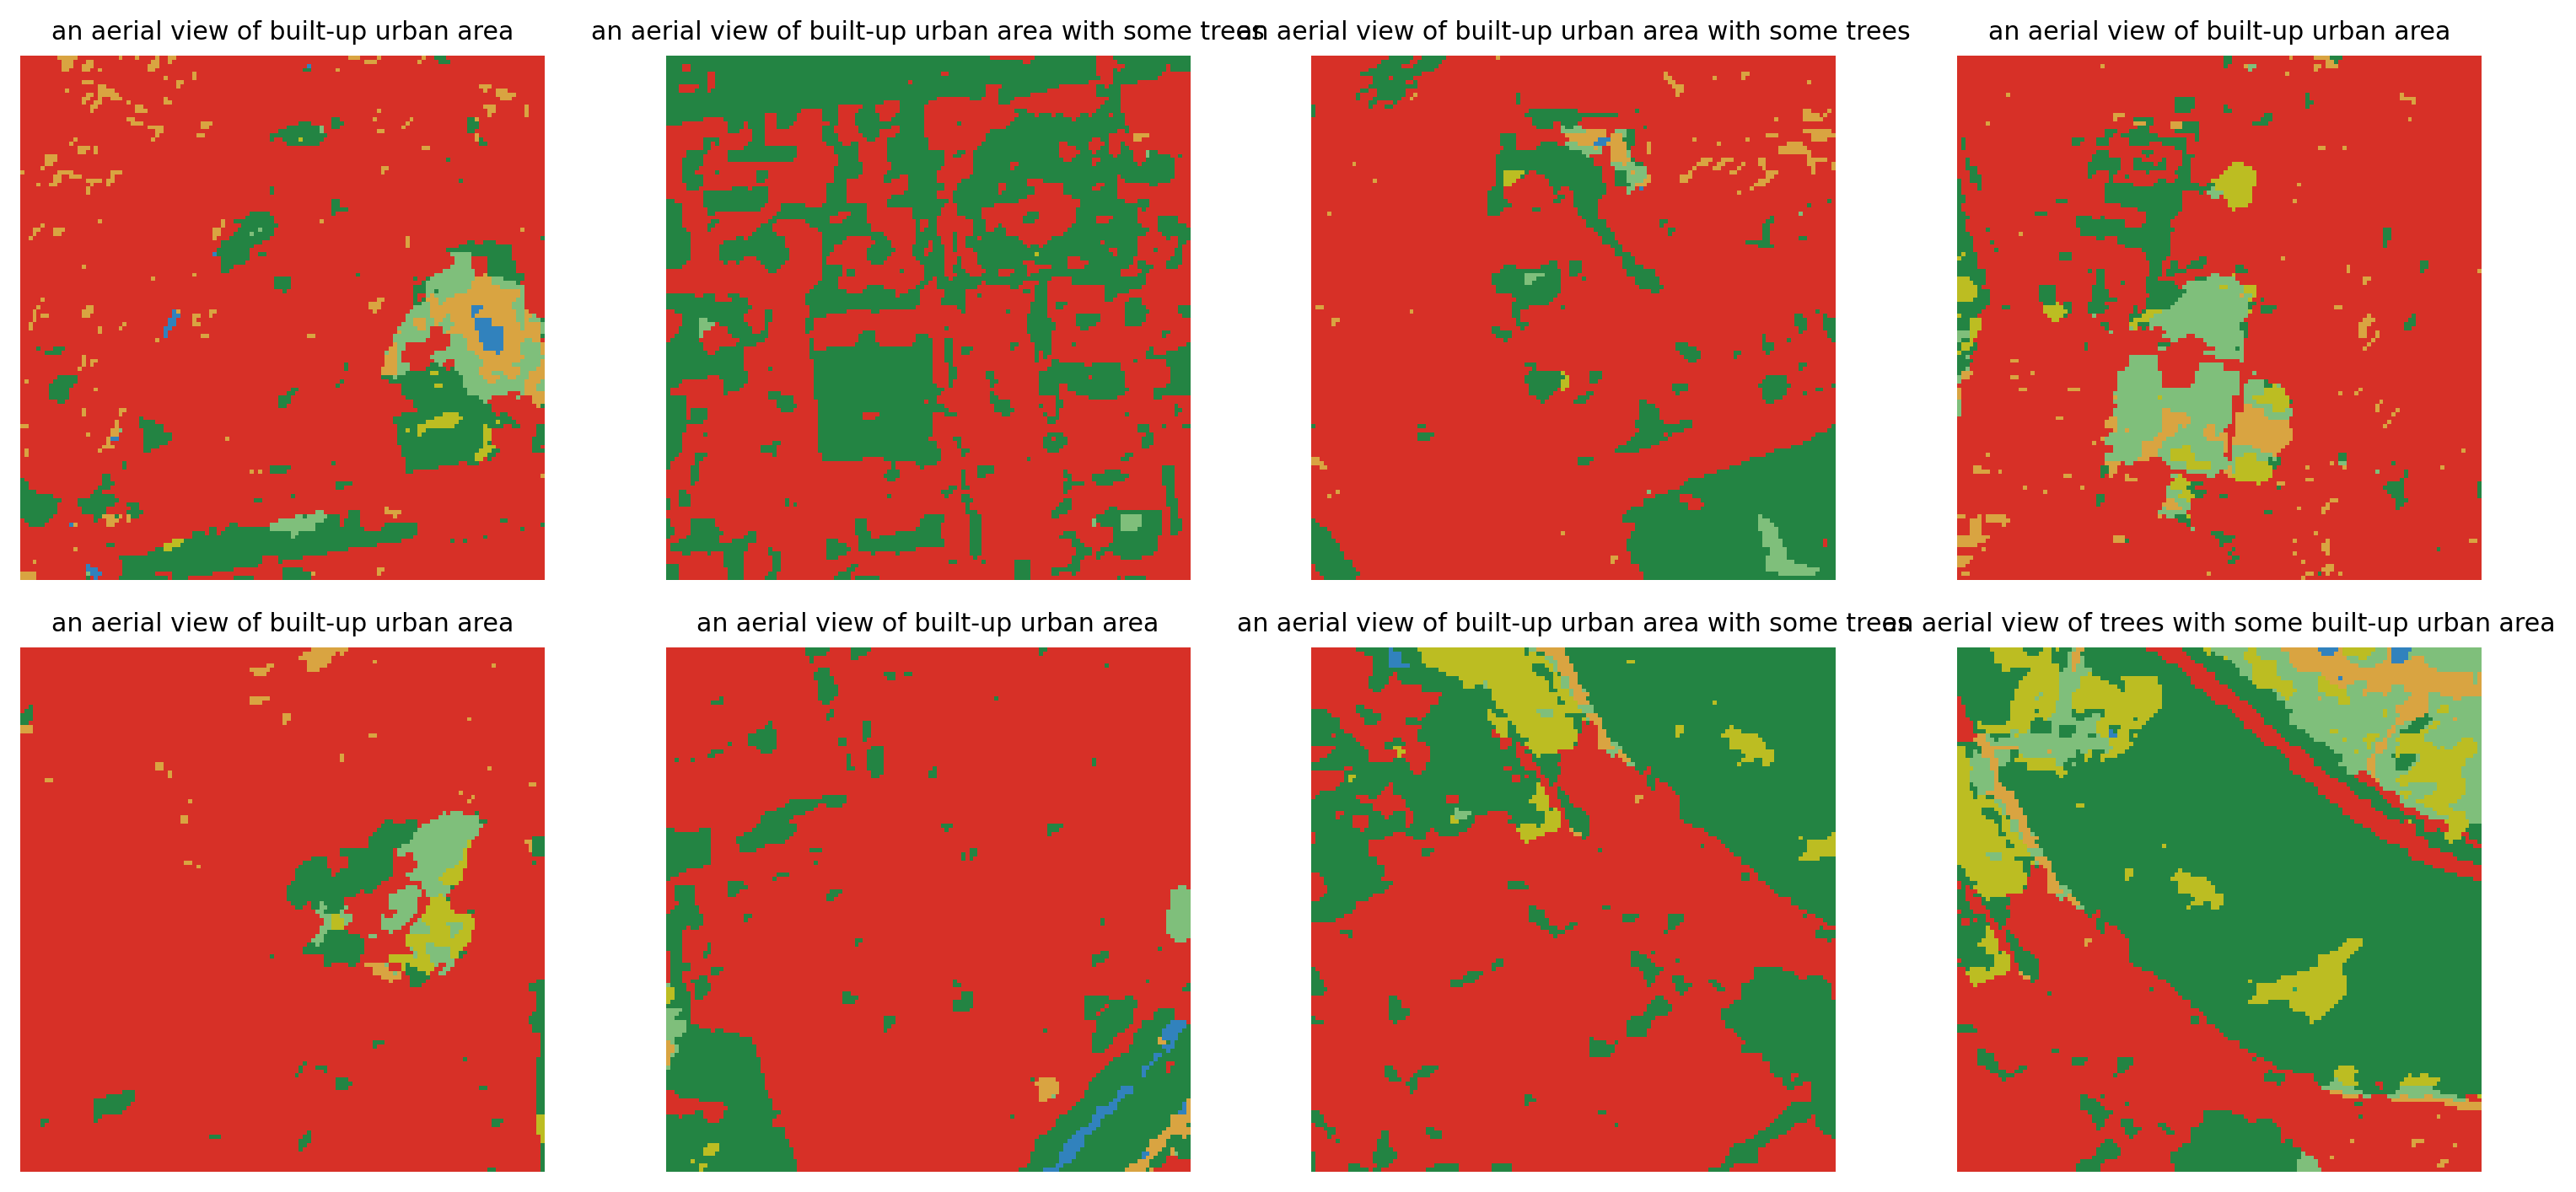

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for i, idx in enumerate([0, 1, 2, 3, 4, 5, 6, 7]):
    rgb, ids, dom_id = dataset[idx]
    caption = dataset.samples[idx][3]
    ax = axes[i // 4, i % 4]
    ax.imshow(rgb.numpy().transpose(1, 2, 0), interpolation="nearest")
    ax.set_title(caption, fontsize=9)
    ax.axis("off")
plt.tight_layout()

## Image encoder

A tiny ViT: linear patch embedding, learned positional embedding, a small transformer encoder, and mean pooling followed by a projection into the joint embedding space.

In [9]:
def patchify(x, patch_size=PATCH_SIZE):
    b, c, h, w = x.shape
    p = patch_size
    gh, gw = h // p, w // p
    return x.reshape(b, c, gh, p, gw, p).permute(0, 2, 4, 1, 3, 5).reshape(b, gh * gw, c * p * p)


class TinyImageEncoder(nn.Module):
    def __init__(self, hidden=IMG_HIDDEN, depth=3, heads=4, embed_dim=EMBED_DIM):
        super().__init__()
        token_dim = NUM_INPUT_CHANNELS * PATCH_SIZE * PATCH_SIZE
        self.patch_embed = nn.Linear(token_dim, hidden)
        self.pos_embed = nn.Parameter(torch.zeros(1, NUM_PATCHES, hidden))
        layer = nn.TransformerEncoderLayer(
            d_model=hidden, nhead=heads, dim_feedforward=4 * hidden,
            dropout=0.0, activation="gelu", batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(hidden)
        self.proj = nn.Linear(hidden, embed_dim)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        z = self.patch_embed(patchify(x))
        z = self.encoder(z + self.pos_embed)
        z = self.norm(z).mean(dim=1)
        return self.proj(z)

## Text encoder

A tiny Transformer over our small vocabulary. We add a learned `[CLS]`-style position-0 vector and pool from the position right after `[EOS]`, just like CLIP does — except since EOS is at a variable position, we use mean pooling over non-pad tokens.

In [10]:
class TinyTextEncoder(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, hidden=TEXT_HIDDEN, depth=2, heads=4,
                 max_len=MAX_TEXT_LEN, embed_dim=EMBED_DIM):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, hidden, padding_idx=PAD_ID)
        self.pos_embed = nn.Parameter(torch.zeros(1, max_len, hidden))
        layer = nn.TransformerEncoderLayer(
            d_model=hidden, nhead=heads, dim_feedforward=4 * hidden,
            dropout=0.0, activation="gelu", batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(hidden)
        self.proj = nn.Linear(hidden, embed_dim)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, ids):
        # ids: B x L
        z = self.token_embed(ids) + self.pos_embed[:, :ids.size(1)]
        pad_mask = ids == PAD_ID
        z = self.encoder(z, src_key_padding_mask=pad_mask)
        valid = (~pad_mask).float().unsqueeze(-1)
        pooled = (z * valid).sum(dim=1) / valid.sum(dim=1).clamp_min(1.0)
        return self.proj(self.norm(pooled))

## CLIP-style wrapper and InfoNCE loss

We L2-normalize both embeddings, scale the dot product by a learned temperature, and apply symmetric cross-entropy. The diagonal of the similarity matrix is the matching pair for each row / column.

In [11]:
class TinyRSCLIP(nn.Module):
    def __init__(self):
        super().__init__()
        self.image_encoder = TinyImageEncoder()
        self.text_encoder = TinyTextEncoder()
        self.log_temp = nn.Parameter(torch.tensor(np.log(1.0 / TEMP_INIT), dtype=torch.float32))

    def encode_image(self, x):
        z = self.image_encoder(x)
        return F.normalize(z, dim=-1)

    def encode_text(self, ids):
        z = self.text_encoder(ids)
        return F.normalize(z, dim=-1)

    def forward(self, x, ids):
        img = self.encode_image(x)
        txt = self.encode_text(ids)
        logits = self.log_temp.exp() * img @ txt.t()
        return img, txt, logits


def info_nce(logits):
    targets = torch.arange(logits.size(0), device=logits.device)
    return 0.5 * (F.cross_entropy(logits, targets) + F.cross_entropy(logits.t(), targets))


model = TinyRSCLIP().to(device)
n_img = sum(p.numel() for p in model.image_encoder.parameters())
n_txt = sum(p.numel() for p in model.text_encoder.parameters())
print(f"image encoder params: {n_img/1e6:.2f}M")
print(f"text  encoder params: {n_txt/1e6:.2f}M")
print(f"total params:         {(n_img + n_txt + 1)/1e6:.2f}M")

image encoder params: 0.72M
text  encoder params: 0.42M
total params:         1.14M


## Training loop

We train with AdamW + cosine schedule. The diagonal accuracy of the similarity matrix is a sanity-check metric that should rise quickly — it's the easiest possible retrieval task (find the matching caption inside the same minibatch).

In [12]:
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    totals = {"loss": 0.0, "acc": 0.0, "n": 0}
    for x, ids, _dom_id in loader:
        x = x.to(device)
        ids = ids.to(device)
        _img, _txt, logits = model(x, ids)
        loss = info_nce(logits)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        # CLIP-style temperature clamp
        with torch.no_grad():
            model.log_temp.clamp_(np.log(1.0), np.log(100.0))
        optimizer.step()

        with torch.no_grad():
            acc = (logits.argmax(dim=1) == torch.arange(x.size(0), device=device)).float().mean()
        bs = x.size(0)
        totals["loss"] += loss.item() * bs
        totals["acc"] += acc.item() * bs
        totals["n"] += bs

    scheduler.step()
    row = {k: totals[k] / totals["n"] for k in ["loss", "acc"]}
    row["epoch"] = epoch
    row["temp"] = float(1.0 / model.log_temp.exp().item())
    history.append(row)
    print(f"epoch {epoch:02d} | InfoNCE {row['loss']:.4f} | batch acc {row['acc']:.3f} | temperature {row['temp']:.4f}")

epoch 01 | InfoNCE 2.9600 | batch acc 0.086 | temperature 0.0700
epoch 02 | InfoNCE 2.6501 | batch acc 0.130 | temperature 0.0700
epoch 03 | InfoNCE 2.6006 | batch acc 0.143 | temperature 0.0700
epoch 04 | InfoNCE 2.5840 | batch acc 0.135 | temperature 0.0701
epoch 05 | InfoNCE 2.5504 | batch acc 0.130 | temperature 0.0701
epoch 06 | InfoNCE 2.5128 | batch acc 0.154 | temperature 0.0702
epoch 07 | InfoNCE 2.4640 | batch acc 0.180 | temperature 0.0702
epoch 08 | InfoNCE 2.4028 | batch acc 0.188 | temperature 0.0701
epoch 09 | InfoNCE 2.3958 | batch acc 0.177 | temperature 0.0701
epoch 10 | InfoNCE 2.4084 | batch acc 0.193 | temperature 0.0701
epoch 11 | InfoNCE 2.4879 | batch acc 0.180 | temperature 0.0701
epoch 12 | InfoNCE 2.4719 | batch acc 0.174 | temperature 0.0702
epoch 13 | InfoNCE 2.3976 | batch acc 0.193 | temperature 0.0703
epoch 14 | InfoNCE 2.3577 | batch acc 0.198 | temperature 0.0702
epoch 15 | InfoNCE 2.3473 | batch acc 0.203 | temperature 0.0702
epoch 16 | InfoNCE 2.3150

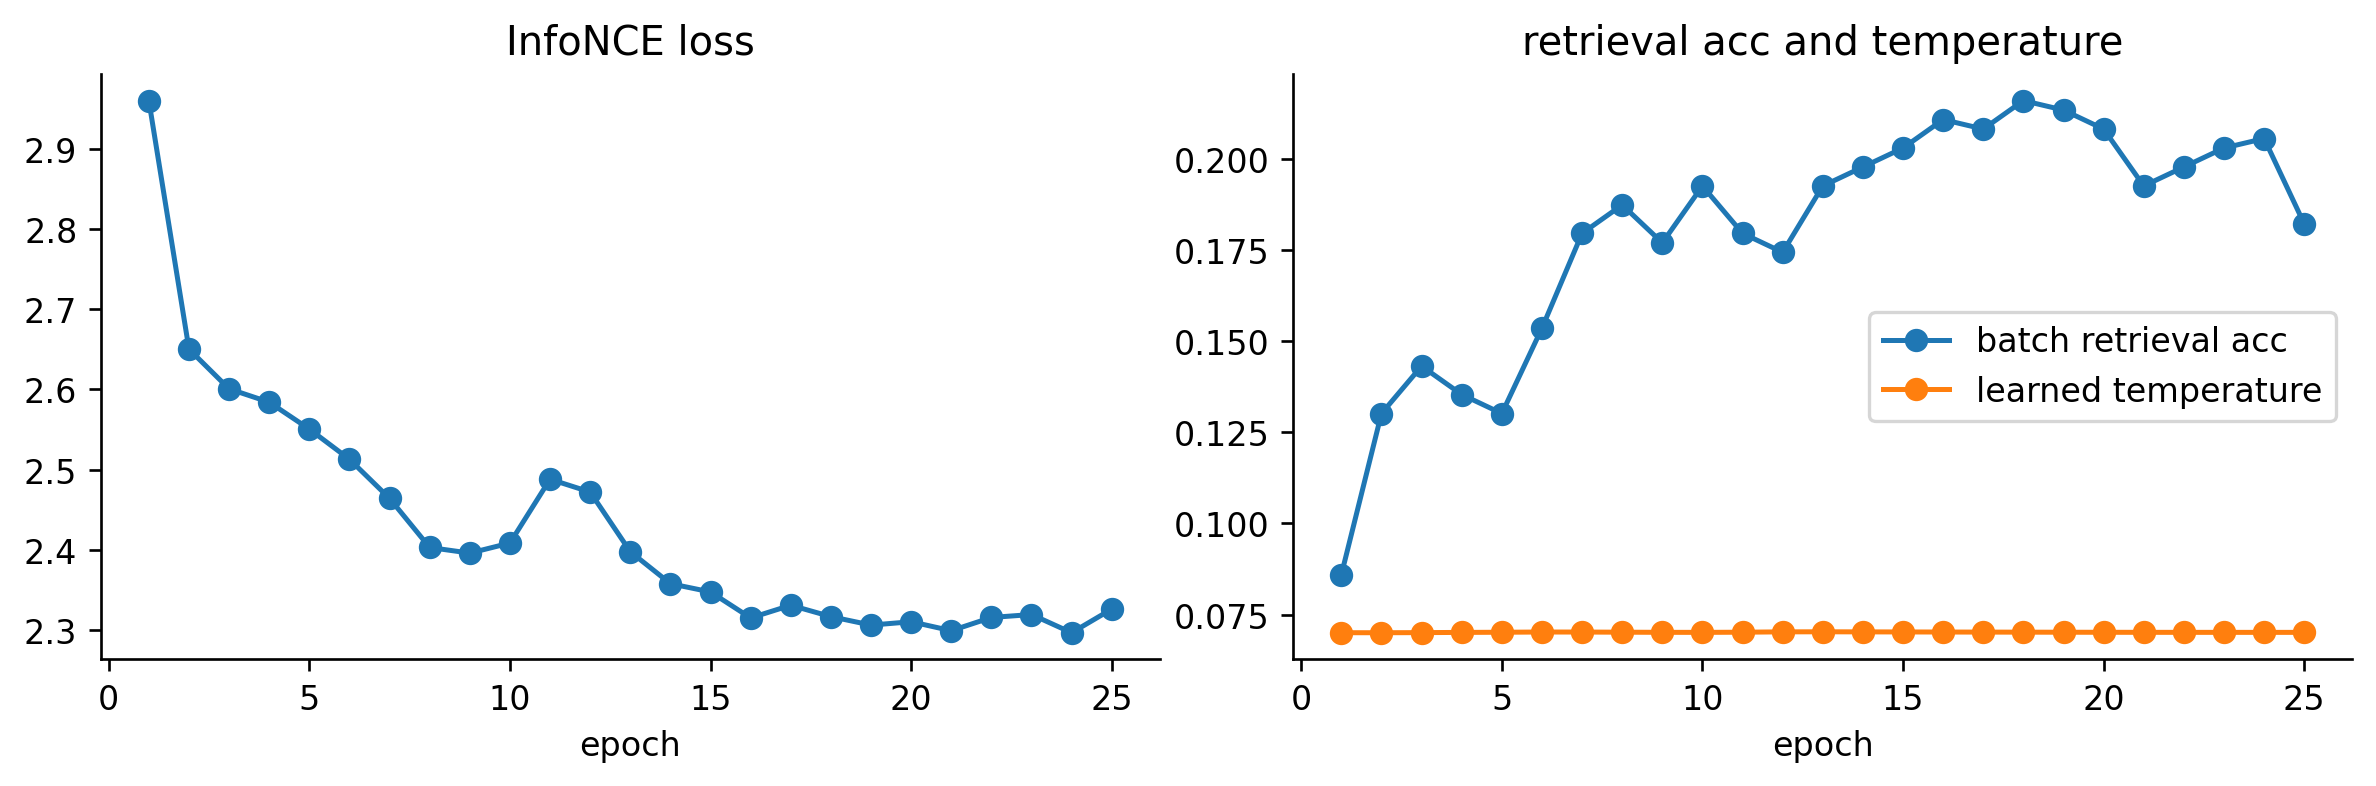

In [13]:
epochs = [h["epoch"] for h in history]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(epochs, [h["loss"] for h in history], marker="o")
axes[0].set_title("InfoNCE loss")
axes[0].set_xlabel("epoch")

axes[1].plot(epochs, [h["acc"] for h in history], marker="o", label="batch retrieval acc")
axes[1].plot(epochs, [h["temp"] for h in history], marker="o", label="learned temperature")
axes[1].set_title("retrieval acc and temperature")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()

## Zero-shot land-cover classification

The classic CLIP recipe: build one text embedding per class using a fixed template, then for each chip pick the class whose text embedding has the highest cosine similarity to the chip's image embedding.

This uses **only the dominant collapsed class** as ground truth. The model was never trained against this label directly — it only saw image / caption pairs.

In [14]:
model.eval()
class_prompts = [f"an aerial view of {CLASS_PHRASES[c]}" for c in CLASS_NAMES]
class_token_batch = torch.tensor([tokenize(p) for p in class_prompts], dtype=torch.long, device=device)
with torch.no_grad():
    class_text_emb = model.encode_text(class_token_batch)  # NUM_CLASSES x EMBED_DIM

correct = torch.zeros(NUM_CLASSES, dtype=torch.long)
total = torch.zeros(NUM_CLASSES, dtype=torch.long)
confusion = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)

with torch.no_grad():
    for x, _ids, dom_id in DataLoader(dataset, batch_size=BATCH_SIZE):
        x = x.to(device)
        img_emb = model.encode_image(x)            # B x EMBED_DIM
        sims = img_emb @ class_text_emb.t()        # B x NUM_CLASSES
        pred = sims.argmax(dim=1).cpu()
        for t, p in zip(dom_id, pred):
            confusion[t, p] += 1
            total[t] += 1
            correct[t] += int(t == p)

overall_acc = correct.sum().item() / max(1, total.sum().item())
print(f"overall zero-shot top-1 accuracy on dominant class: {overall_acc:.3f}")
print()
for name, c, t in zip(CLASS_NAMES, correct.tolist(), total.tolist()):
    if t == 0:
        print(f"  {name:18s} (no chips)")
    else:
        print(f"  {name:18s} {c}/{t} = {c/t:.3f}")

overall zero-shot top-1 accuracy on dominant class: 0.956

  tree               44/44 = 1.000
  cropland           238/254 = 0.937
  grass_shrub        (no chips)
  built_up           85/86 = 0.988
  bare_sparse        (no chips)
  water              (no chips)
  wetland_mangrove   (no chips)
  rare_other         (no chips)


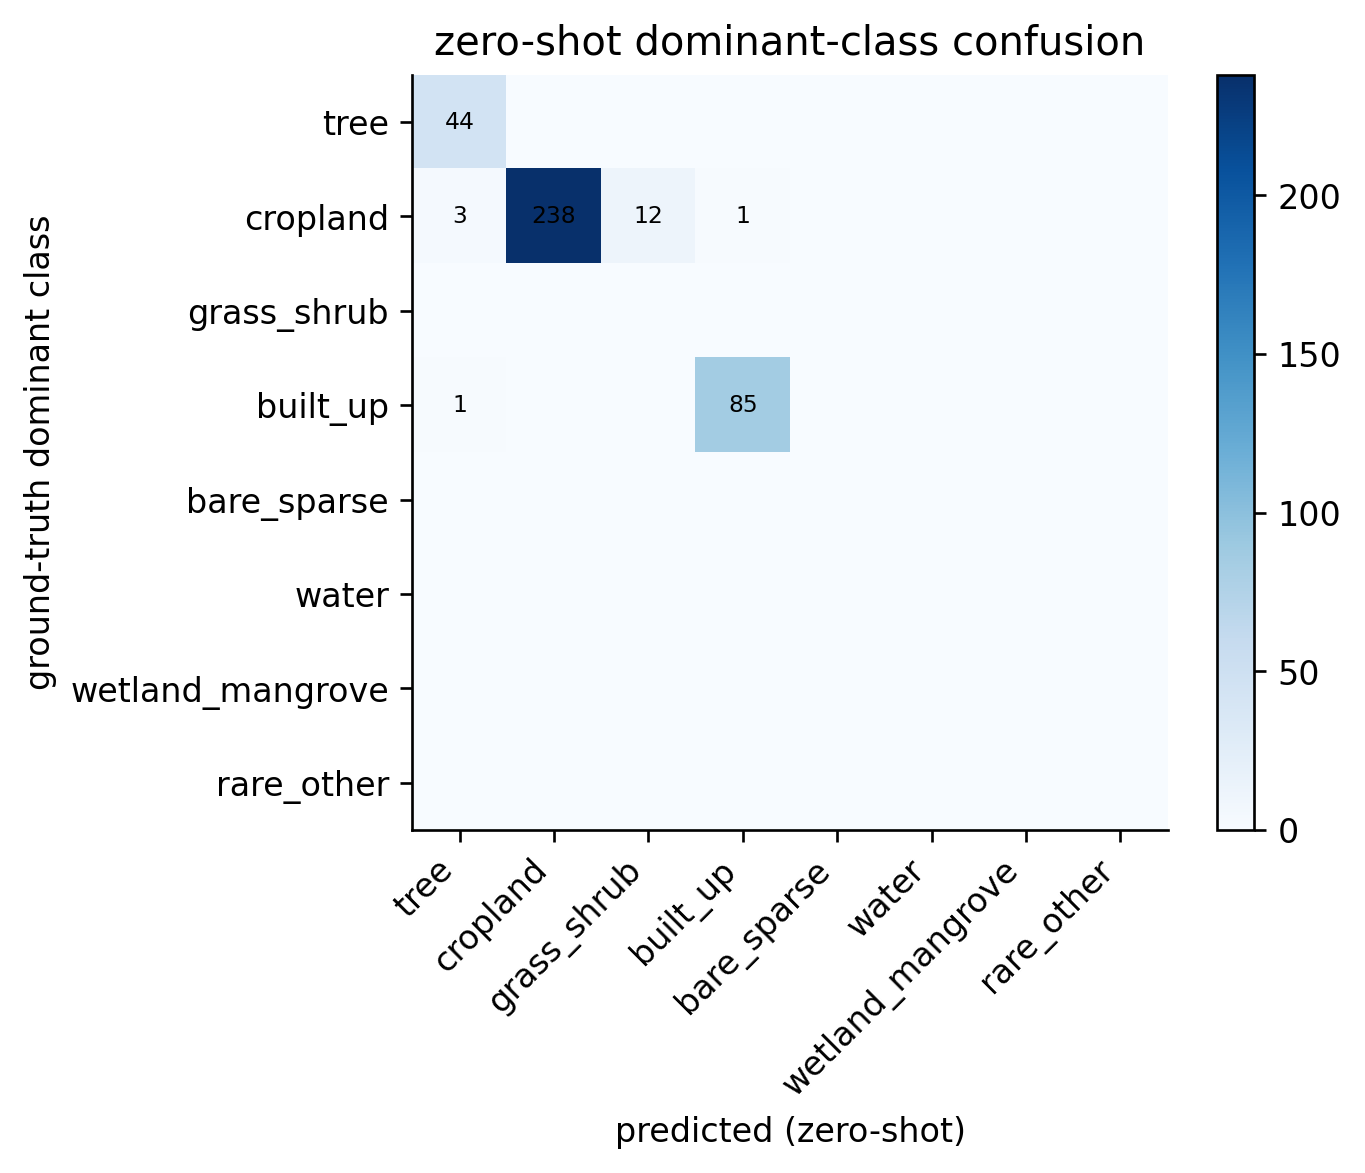

In [15]:
conf_np = confusion.numpy()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(conf_np, cmap="Blues")
ax.set_title("zero-shot dominant-class confusion")
ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
ax.set_xlabel("predicted (zero-shot)")
ax.set_ylabel("ground-truth dominant class")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if conf_np[i, j] > 0:
            ax.text(j, i, str(conf_np[i, j]), ha="center", va="center", fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

## Image-to-text retrieval

For each query chip we rank all 8 class prompts by cosine similarity. Bars in green are the actually-correct dominant class. This is the same panel used in CLIP papers.

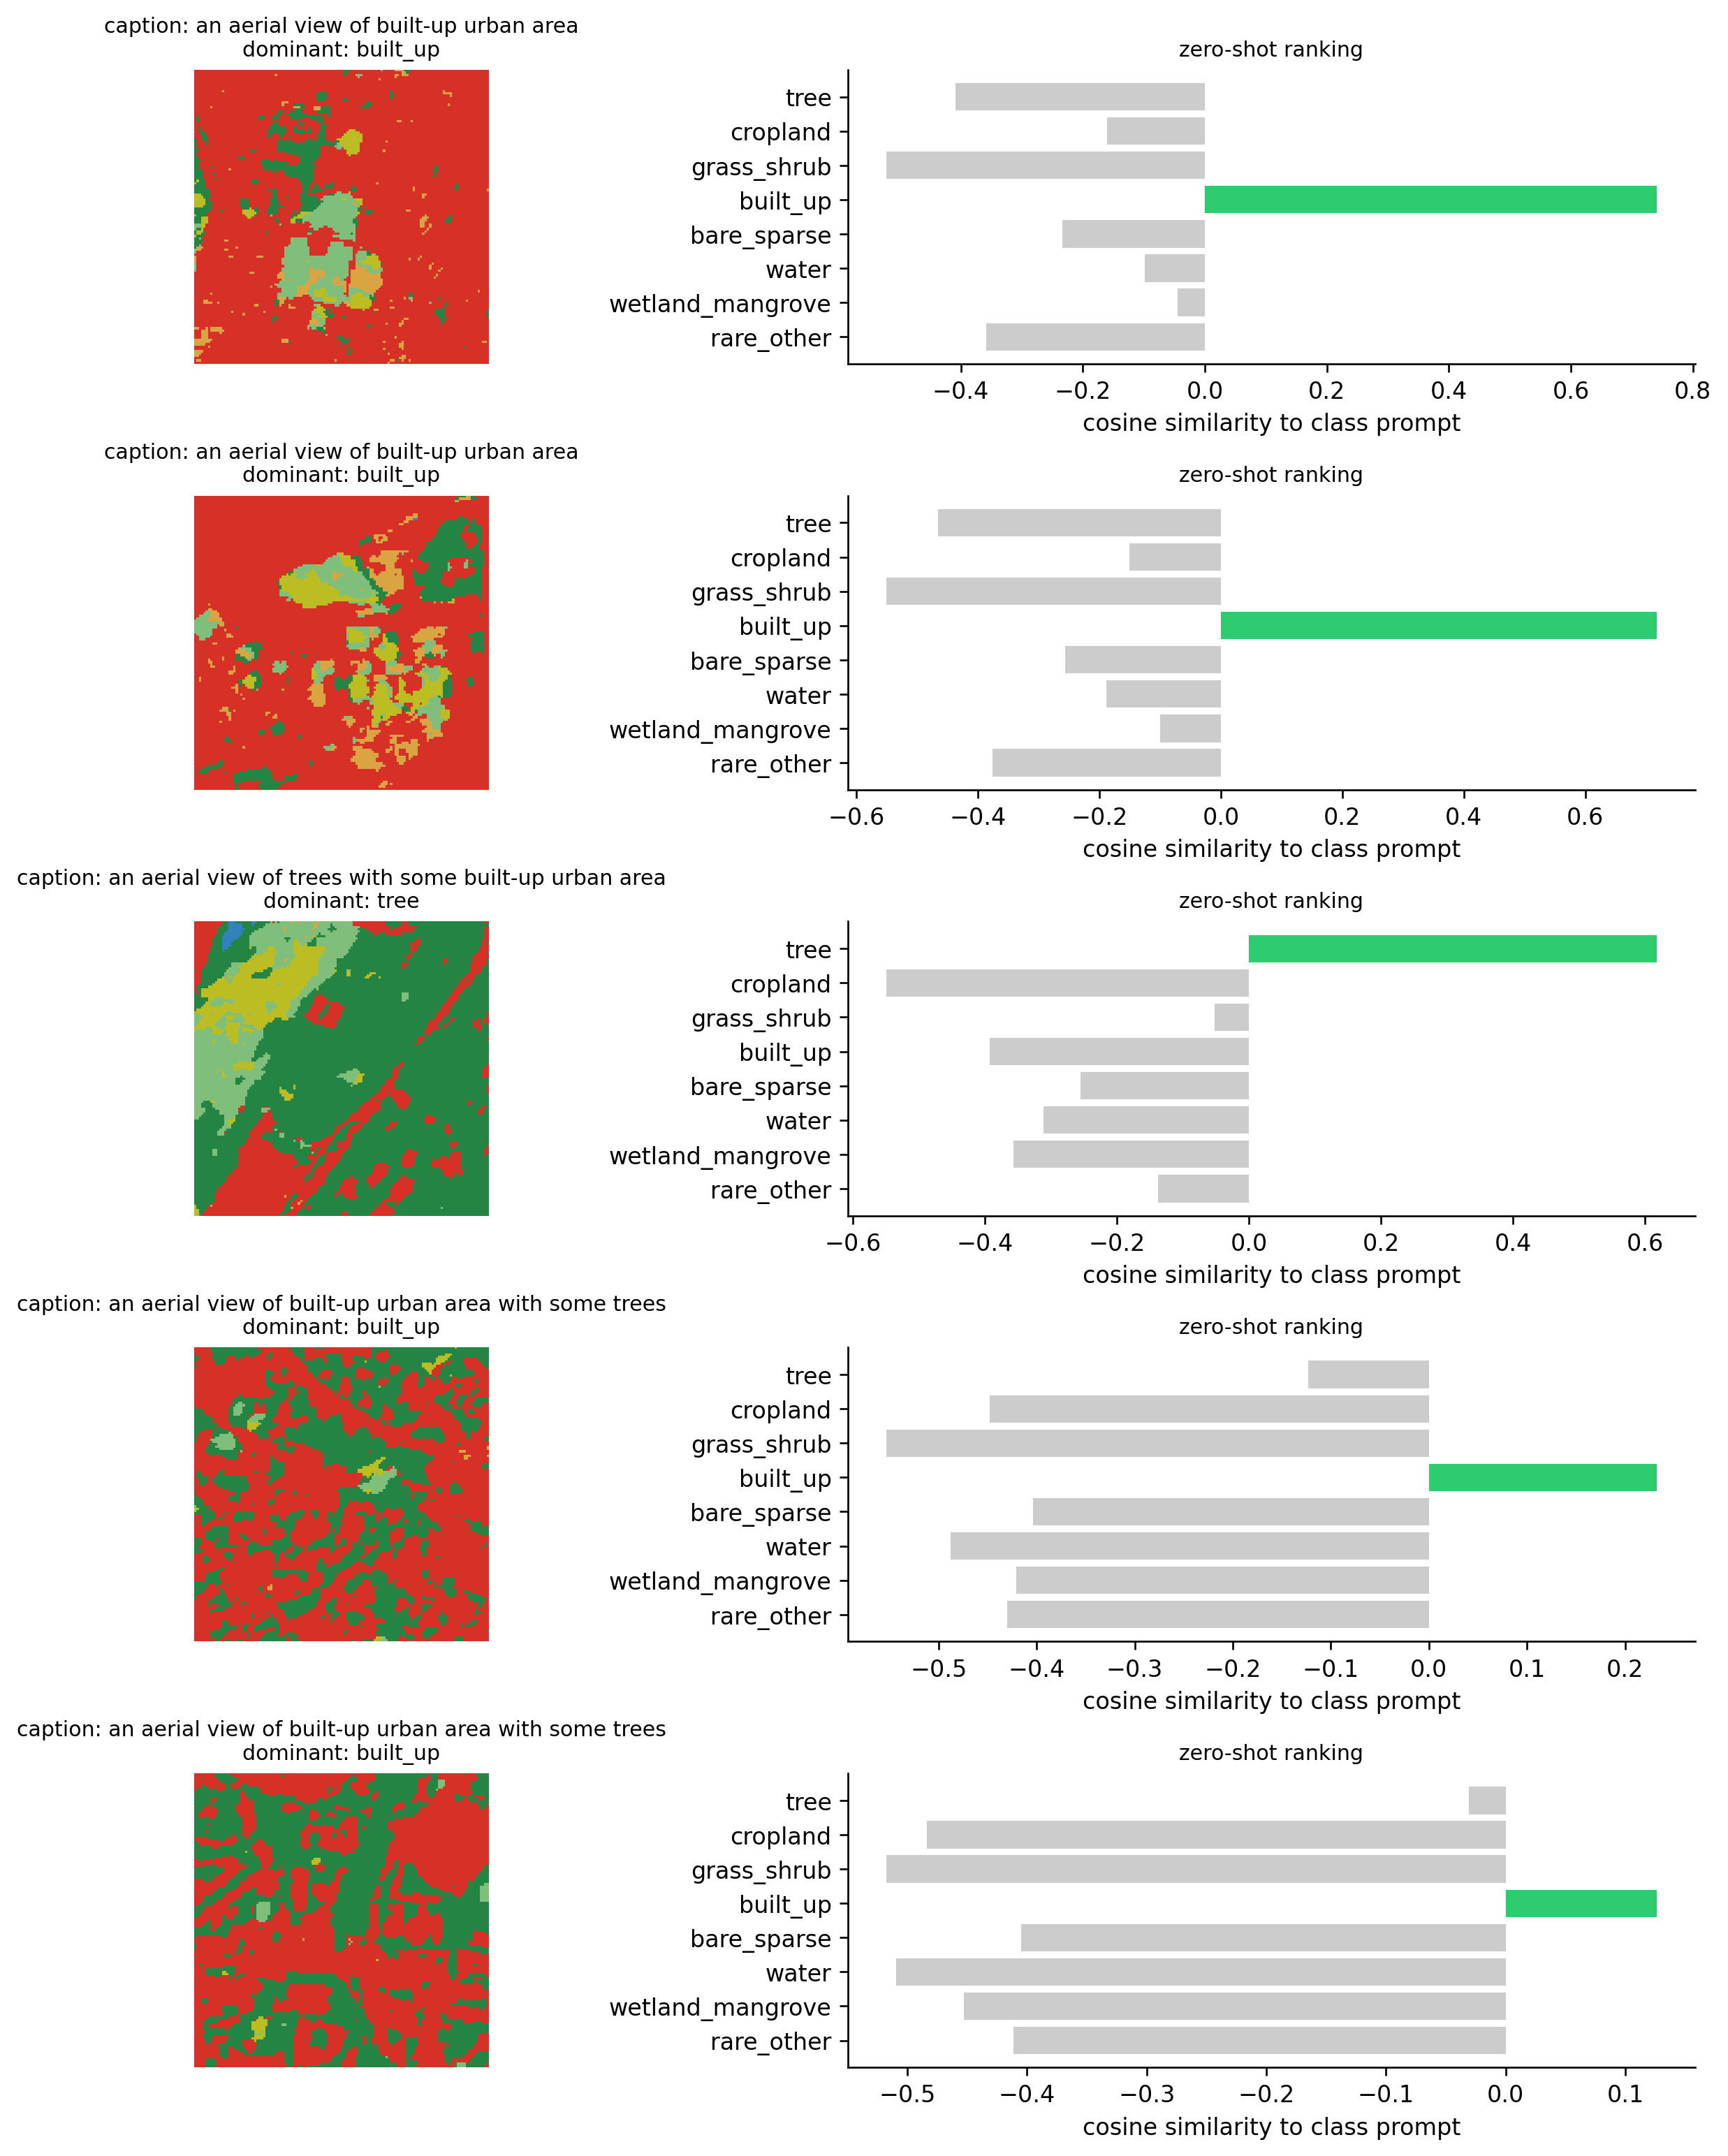

In [16]:
query_indices = [3, 11, 17, 25, 33]
fig, axes = plt.subplots(len(query_indices), 2, figsize=(11, 2.6 * len(query_indices)))
for row, idx in enumerate(query_indices):
    rgb, _ids, dom_id = dataset[idx]
    caption = dataset.samples[idx][3]
    with torch.no_grad():
        img_emb = model.encode_image(rgb.unsqueeze(0).to(device))
        sims = (img_emb @ class_text_emb.t()).cpu()[0]

    axes[row, 0].imshow(rgb.numpy().transpose(1, 2, 0), interpolation="nearest")
    axes[row, 0].set_title(f"caption: {caption}\ndominant: {CLASS_NAMES[dom_id]}", fontsize=9)
    axes[row, 0].axis("off")

    bar_colors = [
        "#2ecc71" if i == dom_id.item() else "#cccccc"
        for i in range(NUM_CLASSES)
    ]
    axes[row, 1].barh(CLASS_NAMES, sims.numpy(), color=bar_colors)
    axes[row, 1].invert_yaxis()
    axes[row, 1].set_xlabel("cosine similarity to class prompt")
    axes[row, 1].set_title("zero-shot ranking", fontsize=9)
plt.tight_layout()

## Image-to-image retrieval

A second use of CLIP-style embeddings: nearest-neighbor search inside the chip set. Given a query chip, sort the rest by cosine similarity in the joint space, and show the closest ones. Chips that share a dominant class should cluster.

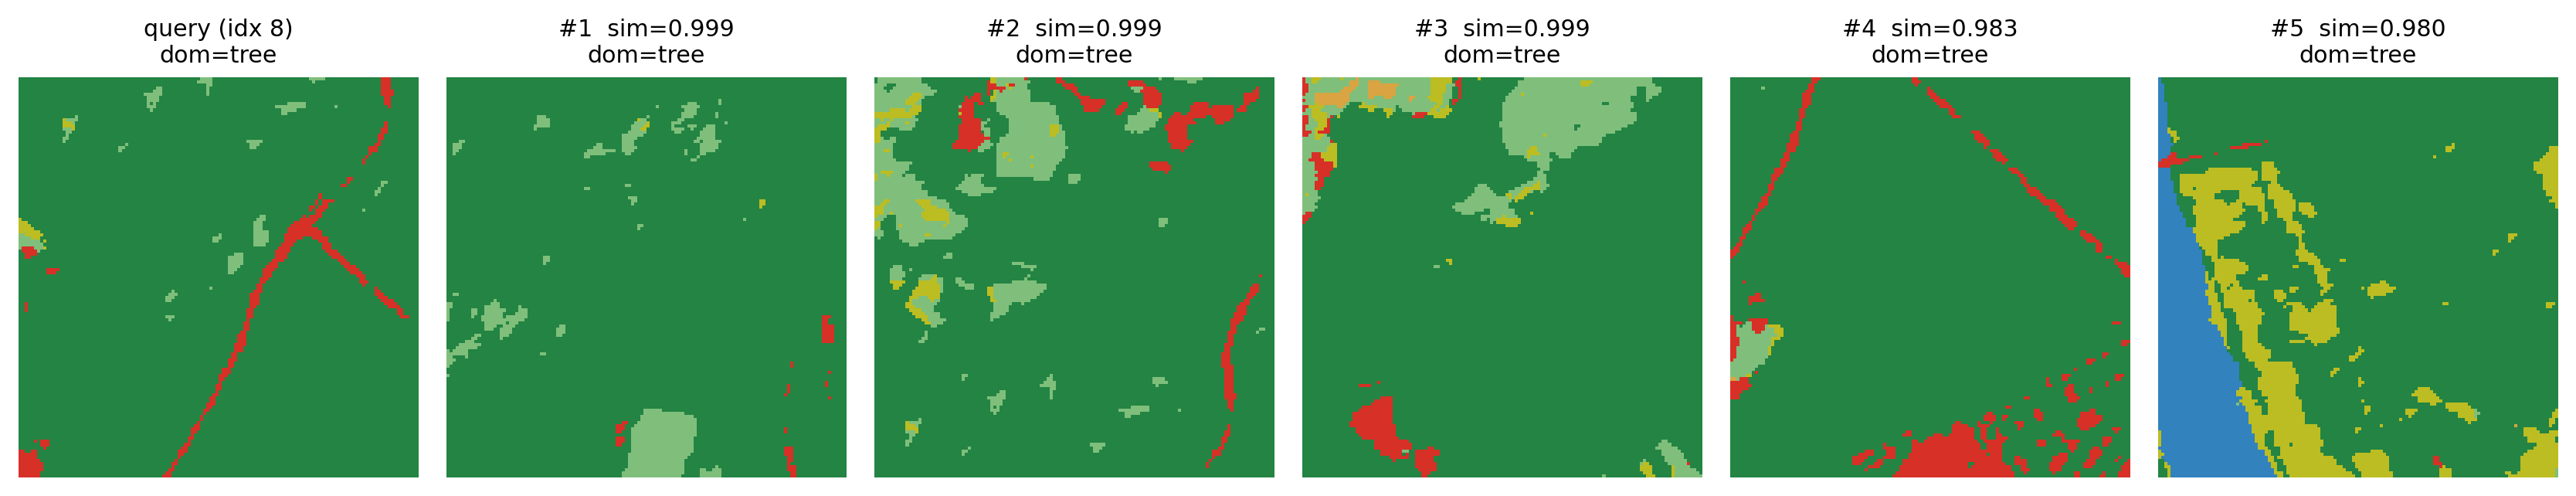

In [17]:
all_img_emb = []
all_dom = []
with torch.no_grad():
    for x, _ids, dom_id in DataLoader(dataset, batch_size=BATCH_SIZE):
        x = x.to(device)
        all_img_emb.append(model.encode_image(x).cpu())
        all_dom.append(dom_id)
all_img_emb = torch.cat(all_img_emb)
all_dom = torch.cat(all_dom)

query_idx = 8
q_emb = all_img_emb[query_idx]
sims = (all_img_emb @ q_emb).numpy()
order = np.argsort(-sims)
neighbors = [i for i in order if i != query_idx][:5]

fig, axes = plt.subplots(1, 6, figsize=(14, 2.6))
q_rgb, _, q_dom = dataset[query_idx]
axes[0].imshow(q_rgb.numpy().transpose(1, 2, 0), interpolation="nearest")
axes[0].set_title(f"query (idx {query_idx})\ndom={CLASS_NAMES[q_dom]}", fontsize=9)
axes[0].axis("off")
for col, n_idx in enumerate(neighbors, start=1):
    n_rgb, _, n_dom = dataset[int(n_idx)]
    axes[col].imshow(n_rgb.numpy().transpose(1, 2, 0), interpolation="nearest")
    axes[col].set_title(f"#{col}  sim={sims[n_idx]:.3f}\ndom={CLASS_NAMES[n_dom]}", fontsize=9)
    axes[col].axis("off")
plt.tight_layout()

## What does it cost? Token + pair scale

For this notebook:

- chips: `384`
- caption tokens / chip: at most `16` (`[SOS]` + 6-12 words + `[EOS]` + padding)
- image tokens / chip: `64`
- training pairs per epoch: `384` (one positive + `B-1` negatives in each minibatch)
- epochs: `25`
- total InfoNCE pair evaluations: `~9.6K` minibatch positives + `~308K` in-batch negatives

For a real RS-CLIP run on Sentinel-2 + caption banks:

- chips: `1M`
- caption length: `~40-60` tokens (real captions, not templated)
- joint embedding: `512` or `768`
- batch size: `4096-32768` for healthy contrastive learning,
- epochs: `30-100`.

The lesson: contrastive learning is **pair-hungry** much more than parameter-hungry. Scaling RS-CLIP is mostly about (a) caption diversity and (b) very large effective batch sizes (gradient accumulation, distributed all-gather).

## What changes for real RS-CLIP on BharatEO?

Keep:

- the chip / patch geometry and the multi-ROI sampling story,
- the InfoNCE / symmetric-CE loss,
- the L2-normalized joint embedding and learned temperature,
- the zero-shot classification recipe (text-prompt-per-class, cosine similarity).

Change:

- input from palette RGB to Sentinel-2 reflectance (or Sentinel-2 + Sentinel-1 SAR for full RS-CLIP),
- captions from class-template strings to a real caption bank: WorldCover-derived natural-language descriptions, OpenStreetMap tags, Wikipedia-style place captions, India-specific land-use vocabulary,
- text encoder from a 2-layer transformer over a 30-word vocabulary to a real subword tokenizer (BPE / sentencepiece) over a 30K-50K vocabulary, possibly initialized from a pretrained encoder,
- evaluation from in-domain dominant-class accuracy to held-out tasks: BigEarthNet, EuroSAT, BharatEO downstream tasks, or text-conditioned retrieval over India.

The pedagogical point: you can get the **shape** of a remote-sensing CLIP model — encoders, contrastive loss, prompt-based zero-shot — into a single notebook and run it on a laptop, and the upgrade path to a real BharatEO RS-CLIP is mostly about (a) replacing inputs with real reflectance and (b) using bigger, more diverse captions with bigger batches.